In [39]:
import pandas as pd

# movies 

In [40]:
movies = pd.read_csv("../data/movies.csv")

In [41]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [42]:
movies.shape

(9742, 3)

In [43]:
movies.info

<bound method DataFrame.info of       movieId                                      title  \
0           1                           Toy Story (1995)   
1           2                             Jumanji (1995)   
2           3                    Grumpier Old Men (1995)   
3           4                   Waiting to Exhale (1995)   
4           5         Father of the Bride Part II (1995)   
...       ...                                        ...   
9737   193581  Black Butler: Book of the Atlantic (2017)   
9738   193583               No Game No Life: Zero (2017)   
9739   193585                               Flint (2017)   
9740   193587        Bungo Stray Dogs: Dead Apple (2018)   
9741   193609        Andrew Dice Clay: Dice Rules (1991)   

                                           genres  
0     Adventure|Animation|Children|Comedy|Fantasy  
1                      Adventure|Children|Fantasy  
2                                  Comedy|Romance  
3                            Comedy|Dra

In [44]:
movies.describe(include="all")

,movieId,title,genres
count,9742.000000,9742,9742
unique,NaN,9737,951
top,NaN,Emma (1996),Drama
freq,NaN,2,1053
mean,42200.353623,NaN,NaN
std,52160.494854,NaN,NaN
min,1.000000,NaN,NaN
25%,3248.250000,NaN,NaN
50%,7300.000000,NaN,NaN
75%,76232.000000,NaN,NaN


In [45]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [46]:
movies.duplicated().sum()

np.int64(0)

In [47]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [48]:
duplicated_titles = movies[movies["title"].duplicated(keep=False)].sort_values("title")
duplicated_titles

,movieId,title,genres
4169,6003,Confessions of a Dangerous Mind (2002),Comedy|Crime|Drama|Thriller
9106,144606,Confessions of a Dangerous Mind (2002),Comedy|Crime|Drama|Romance|Thriller
650,838,Emma (1996),Comedy|Drama|Romance
5601,26958,Emma (1996),Romance
5854,32600,Eros (2004),Drama
9135,147002,Eros (2004),Drama|Romance
2141,2851,Saturn 3 (1980),Adventure|Sci-Fi|Thriller
9468,168358,Saturn 3 (1980),Sci-Fi|Thriller
5931,34048,War of the Worlds (2005),Action|Adventure|Sci-Fi|Thriller
6932,64997,War of the Worlds (2005),Action|Sci-Fi


In [49]:
# See the different genres and how many times they appear
genres = movies["genres"].str.split("|").explode()

genres.value_counts()

genres
Drama                 4361
Comedy                3756
Thriller              1894
Action                1828
Romance               1596
Adventure             1263
Crime                 1199
Sci-Fi                 980
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western                167
IMAX                   158
Film-Noir               87
(no genres listed)      34
Name: count, dtype: int64

In [50]:
# Extract the year from the title
movies["year"] = movies["title"].str.extract(r"\((\d{4})\)")

movies["year"] = pd.to_numeric(movies["year"], errors="coerce")

movies["year"].value_counts().sort_index()

year
1902.0      1
1903.0      1
1908.0      1
1915.0      1
1916.0      4
         ... 
2014.0    278
2015.0    274
2016.0    218
2017.0    147
2018.0     41
Name: count, Length: 106, dtype: int64

In [51]:
# Create a clean title without the release year
movies["clean_title"] = movies["title"].str.replace(r"\s*\(\d{4}\)", "", regex=True)

In [52]:
# Convert genres into a list
movies["genres_list"] = movies["genres"].str.split("|")

In [59]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   movieId      9742 non-null   int64  
 1   title        9742 non-null   str    
 2   genres       9742 non-null   str    
 3   year         9729 non-null   float64
 4   clean_title  9742 non-null   str    
 5   genres_list  9742 non-null   object 
dtypes: float64(1), int64(1), object(1), str(3)
memory usage: 1.0+ MB


In [ ]:
# Create the processed movies dataset in the processed directory
movies.to_csv("../data/processed/movies_processed.csv", index=False)

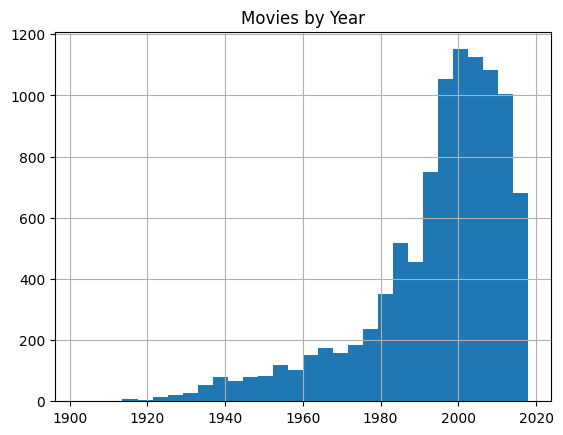

In [ ]:
import matplotlib.pyplot as plt

movies["year"].hist(bins=30)
plt.title("Movies by Year")
plt.show()

## Observations:

- The dataset contains 9,742 movies
- There are no missing values and no duplicated rows
- Some movies appear multiple times with different movieIds, they were preserved as they represent a little part of the total and there are ratings linked to them
- The movie release year was extacted from the 
- There are 13 movies title which contain no year. Since they represent a very small percentage of the dataset, they have been kept and their year is left as missing (NaN)
- There are 34 movies which don't have genres

## ratings

In [54]:
ratings = pd.read_csv("../data/ratings.csv")
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
